In [1]:
%pip install -q baccoemu

Note: you may need to restart the kernel to use updated packages.


In [7]:
# -*- coding: utf-8 -*-
"""
Explore baccoemu linear matter power spectrum emulator
"""

import baccoemu

def explore_linear_emulator():
    """
    Load the baccoemu linear emulator and print k-range + parameter bounds
    """
    # Load the emulator
    emulator = baccoemu.Matter_powerspectrum()
    
    # Print k-range for linear emulator
    kmin = emulator.emulator['linear']['k'].min()
    kmax = emulator.emulator['linear']['k'].max()
    print(f"Linear emulator valid k-range: {kmin:.2e} to {kmax:.2e} h/Mpc")
    
    # Explicitly print min and max k using your requested line
    print(emulator.emulator['linear']['k'].min(), emulator.emulator['linear']['k'].max())
    
    # Print free parameters and their bounds
    print("\nCosmological parameters and bounds:")
    for key, bound in zip(emulator.emulator['linear']['keys'], emulator.emulator['linear']['bounds']):
        print(f"  {key:12s} : {bound}")

if __name__ == "__main__":
    explore_linear_emulator()

Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator...
Baryonic Emulator loaded in memory.
Linear emulator valid k-range: 1.00e-04 to 5.00e+01 h/Mpc
0.0001 49.99999999999999

Cosmological parameters and bounds:
  omega_cold   : [0.06 0.7 ]
  omega_baryon : [0.03 0.07]
  hubble       : [0.5 0.9]
  neutrino_mass : [0. 1.]
  w0           : [-2.  -0.5]
  wa           : [-0.5  0.5]
  expfactor    : [0.1 1. ]


Generating linear matter power spectrum using baccoemu...
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator...
Baryonic Emulator loaded in memory.
k range: 1.0e-04 to 5.0e+01 h/Mpc
Number of k points: 200
Peak power (cold matter): 2.6e+04 h^-3 Mpc^3
Peak power (total matter): 2.6e+04 h^-3 Mpc^3


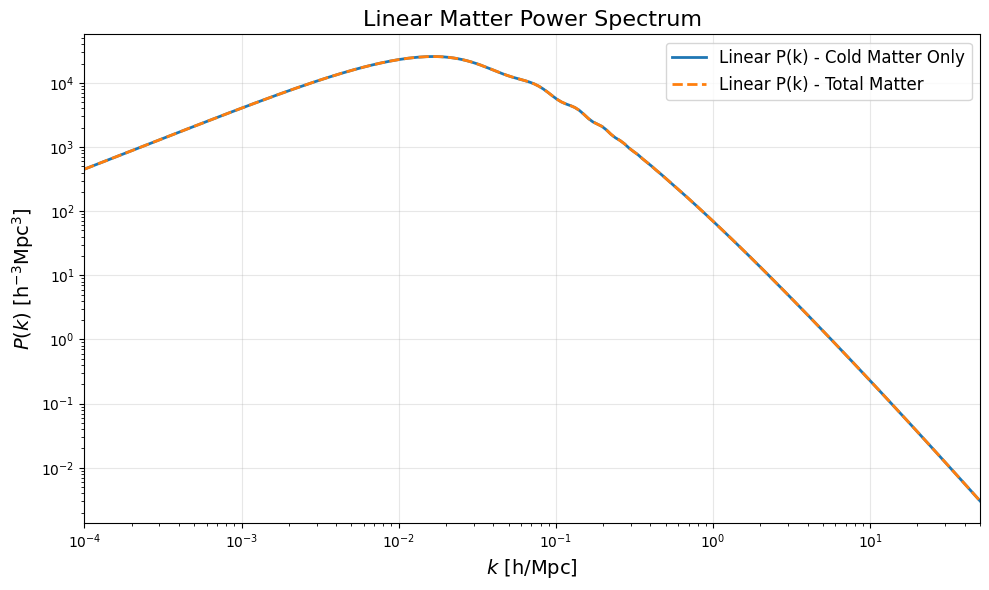

In [8]:
# -*- coding: utf-8 -*-
"""
Linear Matter Power Spectrum Generator using baccoemu
"""

import numpy as np
import matplotlib.pyplot as plt
import baccoemu

def generate_linear_power_spectrum():
    """
    Generate and plot linear matter power spectrum using baccoemu emulator
    """
    
    # Initialize the matter power spectrum emulator
    emulator = baccoemu.Matter_powerspectrum()
    
    # Define wavenumber array (k in h/Mpc)
    # Linear emulator is valid from k = 0.0001 to 50 h/Mpc
    k = np.logspace(-4, np.log10(50), 200)  # 200 points from 0.0001 to 50 h/Mpc
    
    # Define cosmological parameters (fiducial ΛCDM cosmology)
    params = {
        'omega_cold'    : 0.315,    # Cold dark matter density parameter
        'sigma8_cold'   : 0.83,     # RMS amplitude of matter fluctuations at 8 Mpc/h
        'omega_baryon'  : 0.05,     # Baryon density parameter  
        'ns'            : 0.96,     # Scalar spectral index
        'hubble'        : 0.67,     # Dimensionless Hubble parameter (H0/100)
        'neutrino_mass' : 0.0,      # Total neutrino mass in eV
        'w0'            : -1.0,     # Dark energy equation of state parameter
        'wa'            : 0.0,      # Dark energy equation of state evolution
        'expfactor'     : 1.0       # Scale factor (a = 1/(1+z)), 1 = present day
    }
    
    # Compute linear matter power spectrum
    # cold=True: cold matter only, cold=False: total matter (including baryons)
    k_out_cold, pk_lin_cold = emulator.get_linear_pk(k=k, cold=True, **params)
    k_out_total, pk_lin_total = emulator.get_linear_pk(k=k, cold=False, **params)
    
    return k_out_cold, pk_lin_cold, pk_lin_total

def plot_linear_power_spectrum(k, pk_cold, pk_total):
    """
    Plot the linear matter power spectrum
    """
    
    plt.figure(figsize=(10, 6))
    
    # Plot both cold matter and total matter power spectra
    plt.loglog(k, pk_cold, label='Linear P(k) - Cold Matter Only', linewidth=2)
    plt.loglog(k, pk_total, label='Linear P(k) - Total Matter', linewidth=2, linestyle='--')
    
    # Formatting
    plt.xlabel(r'$k$ [h/Mpc]', fontsize=14)
    plt.ylabel(r'$P(k)$ [h$^{-3}$Mpc$^3$]', fontsize=14)
    plt.title('Linear Matter Power Spectrum', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xlim(1e-4, 50)
    
    plt.tight_layout()
    plt.show()

def main():
    """
    Main function to generate and display linear power spectrum
    """
    
    print("Generating linear matter power spectrum using baccoemu...")
    
    # Generate the power spectrum
    k, pk_cold, pk_total = generate_linear_power_spectrum()
    
    # Print some basic info
    print(f"k range: {k.min():.1e} to {k.max():.1e} h/Mpc")
    print(f"Number of k points: {len(k)}")
    print(f"Peak power (cold matter): {pk_cold.max():.1e} h^-3 Mpc^3")
    print(f"Peak power (total matter): {pk_total.max():.1e} h^-3 Mpc^3")
    
    # Plot the results
    plot_linear_power_spectrum(k, pk_cold, pk_total)
    
    return k, pk_cold, pk_total

if __name__ == "__main__":
    # Run the main function
    k, pk_cold, pk_total = main()